# Python Cheat Sheet: Complete Explanation

This notebook provides a detailed explanation of the functions and methods found in the Python Cheat Sheet PDF. It covers Pandas, NumPy, Matplotlib, Seaborn, and other useful Python features in a comprehensive manner.

## Pandas Functions

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

***Explanation:***
This cell imports all the necessary libraries for this notebook: `pandas` for data manipulation, `numpy` for numerical operations, `matplotlib.pyplot` for basic plotting, and `seaborn` for advanced statistical plotting.

**Note on Excel Files:**
Working with Excel files (`.xlsx`) in pandas requires an additional library called `openpyxl`. If you encounter errors related to Excel files, you can install it by running the following command in your terminal or a code cell:
```
pip install openpyxl
```

### Data I/O

In [52]:
# Create dummy files for demonstration
pd.DataFrame({'A':[1,2], 'B':['Test1', 'Test2']}).to_csv('data.csv', index=False)
pd.DataFrame({'A':[1,2], 'B':['Test1', 'Test2']}).to_excel('data.xlsx', index=False)

***Explanation:***
This code block prepares the environment for the I/O examples. It creates two files: `data.csv` and `data.xlsx`. Both files contain the same simple DataFrame, allowing the subsequent `read` functions to have files to work with.

**`pd.read_csv(file)`**: Read a CSV file into a DataFrame.

In [53]:
df_csv = pd.read_csv('data.csv')
print(df_csv)

   A      B
0  1  Test1
1  2  Test2


***Explanation:***
This code reads the `data.csv` file created earlier into a pandas DataFrame called `df_csv` and then prints its content to the screen.

**`pd.read_excel(file)`**: Read an Excel file into a DataFrame.

In [54]:
df_excel = pd.read_excel('data.xlsx')
print(df_excel)

   A      B
0  1  Test1
1  2  Test2


***Explanation:***
Similarly, this code reads the `data.xlsx` file into a DataFrame named `df_excel` and prints its content.

**`df.to_csv(file)`**: Write DataFrame to a CSV file.

In [55]:
df_csv.to_csv('out.csv', index=False)
# You can check your directory for 'out.csv'

***Explanation:***
This code saves the `df_csv` DataFrame to a new file named `out.csv`. The `index=False` argument is important as it prevents pandas from writing the DataFrame's row indices as a column in the CSV file.

**`df.to_excel(file)`**: Write DataFrame to an Excel file.

In [56]:
df_excel.to_excel('out.xlsx', index=False)
# You can check your directory for 'out.xlsx'

***Explanation:***
This code saves the `df_excel` DataFrame to a new Excel file named `out.xlsx`. Again, `index=False` is used to avoid saving the row indices.

### Create Data

**`pd.DataFrame(data)`**: Create a DataFrame.

In [57]:
df = pd.DataFrame({'A': [1, 2, 3], 'B': [4, 5, 6]})
print(df)

   A  B
0  1  4
1  2  5
2  3  6


***Explanation:***
A new DataFrame named `df` is created from a Python dictionary. The dictionary keys (`'A'`, `'B'`) become the column headers, and the lists of values become the data in those columns.

**`pd.Series(data)`**: Create a Series.

In [58]:
s = pd.Series([10, 20, 30])
print(s)

0    10
1    20
2    30
dtype: int64


***Explanation:***
A pandas Series, which is a one-dimensional labeled array, is created from a simple Python list. It is the primary building block for a DataFrame.

### Inspect Data

**`df.head(n)`**: First n rows.

In [59]:
print(df.head(2))

   A  B
0  1  4
1  2  5


***Explanation:***
This code displays the first 2 rows of the `df` DataFrame. The `head()` method is useful for getting a quick look at the beginning of your dataset without displaying the whole thing.

**`df.tail(n)`**: Last n rows.

In [60]:
print(df.tail(2))

   A  B
1  2  5
2  3  6


***Explanation:***
Similar to `head()`, `tail(2)` displays the last 2 rows of the DataFrame. This is useful for verifying that data has been read correctly or for checking the last entries.

**`df.info()`**: Column info & types.

In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   A       3 non-null      int64
 1   B       3 non-null      int64
dtypes: int64(2)
memory usage: 180.0 bytes


***Explanation:***
The `info()` method provides a concise summary of the DataFrame. It shows the data type of each column, the number of non-null values, and the memory usage. It's a critical first step in data exploration.

**`df.describe()`**: Summary statistics.

In [62]:
print(df.describe())

         A    B
count  3.0  3.0
mean   2.0  5.0
std    1.0  1.0
min    1.0  4.0
25%    1.5  4.5
50%    2.0  5.0
75%    2.5  5.5
max    3.0  6.0


***Explanation:***
This code generates descriptive statistics for the numeric columns in the DataFrame. It includes the count, mean, standard deviation, minimum, maximum, and quartile values, giving a quick overview of the data's distribution.

**`df.shape`**: Rows, columns count.

In [63]:
print(df.shape)

(3, 2)


***Explanation:***
The `.shape` attribute returns a tuple representing the dimensionality of the DataFrame. The first value is the number of rows, and the second is the number of columns.

### Select & Filter

**`df['col']`**: Select column.

In [64]:
print(df['A'])

0    1
1    2
2    3
Name: A, dtype: int64


***Explanation:***
This is the basic syntax for selecting a single column from a DataFrame. It returns the column named 'A' as a pandas Series.

**`df[['c1','c2']]`**: Select multiple columns.

In [65]:
print(df[['A', 'B']])

   A  B
0  1  4
1  2  5
2  3  6


***Explanation:***
To select multiple columns, you pass a list of column names inside the brackets. This returns a new DataFrame containing only the specified columns.

**`df.loc[]`**: Label-based select.

In [66]:
print(df.loc[0:1, 'A':'B'])

   A  B
0  1  4
1  2  5


***Explanation:***
`.loc` is used for selection by label. This example selects all rows with index labels from 0 up to and including 1, and all columns with labels from 'A' up to and including 'B'.

**`df.iloc[]`**: Index-based select.

In [67]:
print(df.iloc[0:2, 0:1])

   A
0  1
1  2


***Explanation:***
`.iloc` is used for selection by integer position. This example selects the rows at positions 0 and 1 (the first two rows), and the column at position 0 (the first column).

**`df.query(expr)`**: Filter rows by expression.

In [68]:
print(df.query('A > 1'))

   A  B
1  2  5
2  3  6


***Explanation:***
The `query()` method provides a powerful way to filter a DataFrame using a string expression. This code returns a new DataFrame containing only the rows where the value in column 'A' is greater than 1.

### Missing Data

In [69]:
df_missing = pd.DataFrame({'A': [1, np.nan, 3], 'B': [4, 5, np.nan]})
print("Original DataFrame with missing values:")
print(df_missing)

Original DataFrame with missing values:
     A    B
0  1.0  4.0
1  NaN  5.0
2  3.0  NaN


***Explanation:***
A new DataFrame `df_missing` is created to demonstrate how to handle missing data. `np.nan` is used to represent missing (Not a Number) values.

**`df.isna()`**: Detect missing values.

In [70]:
print(df_missing.isna())

       A      B
0  False  False
1   True  False
2  False   True


***Explanation:***
This method returns a boolean DataFrame of the same size, where `True` indicates the presence of a missing value (NaN) and `False` indicates a valid value.

**`df.notna()`**: Detect non-missing values.

In [71]:
print(df_missing.notna())

       A      B
0   True   True
1  False   True
2   True  False


***Explanation:***
This is the opposite of `isna()`. It returns `True` for every location that contains a non-missing value and `False` for missing values.

**`df.fillna(val)`**: Fill missing values.

In [72]:
print(df_missing.fillna(0))

     A    B
0  1.0  4.0
1  0.0  5.0
2  3.0  0.0


***Explanation:***
This method is used to replace all missing (NaN) values in the DataFrame with a specified value. In this case, every `NaN` is replaced with `0`.

**`df.dropna()`**: Drop rows with NaN.

In [73]:
print(df_missing.dropna())

     A    B
0  1.0  4.0


***Explanation:***
This method removes any row that contains at least one missing value. It returns a new DataFrame with only the complete rows.

## NumPy Functions

### Array Creation

**`np.array(list)`**: Create array from list/tuple.

In [74]:
arr = np.array([1, 2, 3])
print(arr)

[1 2 3]


***Explanation:***
This is the fundamental way to create a NumPy array. It takes a Python list (or tuple) and converts it into a NumPy array.

**`np.zeros(shape)`**: Create array filled with 0s.

In [75]:
zeros_arr = np.zeros((2, 3))
print(zeros_arr)

[[0. 0. 0.]
 [0. 0. 0.]]


***Explanation:***
This function creates a new NumPy array of a specified shape, filled entirely with zeros. The shape `(2, 3)` means 2 rows and 3 columns.

**`np.ones(shape)`**: Create array filled with 1s.

In [76]:
ones_arr = np.ones((3, 2))
print(ones_arr)

[[1. 1.]
 [1. 1.]
 [1. 1.]]


***Explanation:***
Similar to `np.zeros`, this function creates a new array of a given shape, but fills it with ones instead.

**`np.full(shape, val)`**: Create array filled with given value.

In [77]:
full_arr = np.full((2, 2), 7)
print(full_arr)

[[7 7]
 [7 7]]


***Explanation:***
This function creates an array of a specified shape and fills it with a specified constant value. Here, it creates a 2x2 array where every element is `7`.

**`np.eye(n)`**: Identity matrix.

In [78]:
eye_arr = np.eye(4)
print(eye_arr)

[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]


***Explanation:***
This creates a 4x4 identity matrix. An identity matrix is a square matrix with `1`s on the main diagonal and `0`s everywhere else. It is very useful in linear algebra.

**`np.arange(start, stop, step)`**: Evenly spaced values.

In [79]:
arange_arr = np.arange(0, 10, 2)
print(arange_arr)

[0 2 4 6 8]


***Explanation:***
This function creates an array with a sequence of numbers. It starts at `0`, goes up to (but does not include) `10`, and the step between numbers is `2`.

**`np.linspace(start, stop, num)`**: Evenly spaced values (incl. stop).

In [80]:
linspace_arr = np.linspace(0, 1, 5)
print(linspace_arr)

[0.   0.25 0.5  0.75 1.  ]


***Explanation:***
This function creates an array with a specified number of evenly spaced points between a start and stop value. Unlike `arange`, `linspace` includes the stop value. Here, it creates 5 points from 0 to 1.

### Array Info

In [81]:
a = np.array([[1,2,3],[4,5,6]])

***Explanation:***
A 2-dimensional NumPy array (a 2x3 matrix) is created to be used in the following examples demonstrating array attributes.

**`.shape`**: Dimensions of array.

In [82]:
print(a.shape)

(2, 3)


***Explanation:***
The `.shape` attribute returns a tuple indicating the size of the array in each dimension. For the array `a`, it returns `(2, 3)`, meaning 2 rows and 3 columns.

**`.ndim`**: Number of dimensions.

In [83]:
print(a.ndim)

2


***Explanation:***
The `.ndim` attribute returns the number of array dimensions. Since `a` is a 2D matrix, this returns `2`.

**`.size`**: Total number of elements.

In [84]:
print(a.size)

6


***Explanation:***
The `.size` attribute returns the total number of elements in the array, which is the product of the dimensions. For `a`, this is 2 * 3 = 6.

**`.dtype`**: Data type of elements.

In [85]:
print(a.dtype)

int64


***Explanation:***
The `.dtype` attribute returns the data type of the elements in the array. Since the array `a` was created with integers, this will be an integer type (e.g., `int32` or `int64`).

## Matplotlib Functions

### Basic Setup & Plotting

**`%matplotlib inline`**: Show plots in Jupyter.

***Explanation:***
This is a special command for Jupyter notebooks (a 'magic' command) that ensures Matplotlib plots are rendered directly in the output of the cell.

**`plt.plot(x, y)`**: Line plot.

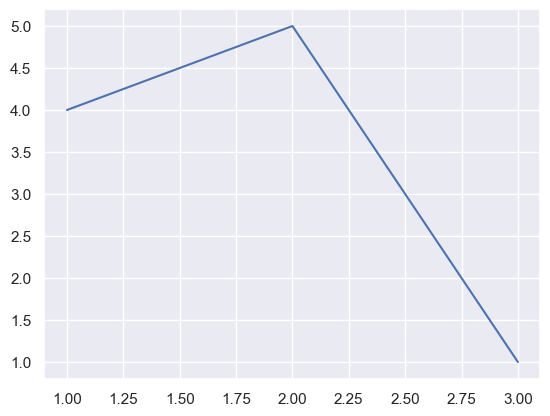

In [86]:
plt.plot([1, 2, 3], [4, 5, 1])
plt.show()

***Explanation:***
This code creates a simple line plot. The first list `[1, 2, 3]` provides the x-coordinates, and the second list `[4, 5, 1]` provides the y-coordinates. `plt.show()` is called to display the generated plot.

**`plt.scatter(x, y)`**: Scatter plot.

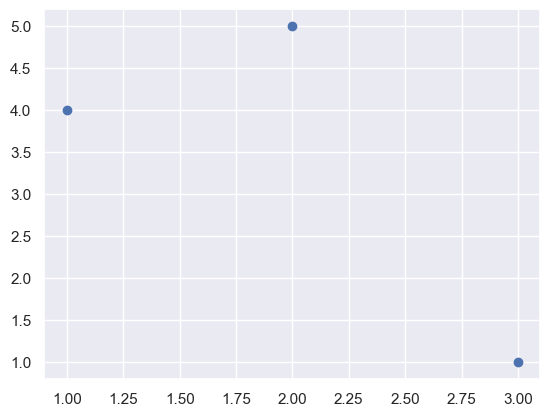

In [87]:
plt.scatter([1, 2, 3], [4, 5, 1])
plt.show()

***Explanation:***
This creates a scatter plot, which is a set of individual points. The x and y coordinates are provided by the two lists. `plt.show()` displays the plot.

**`plt.bar(x, height)`**: Vertical bar chart.

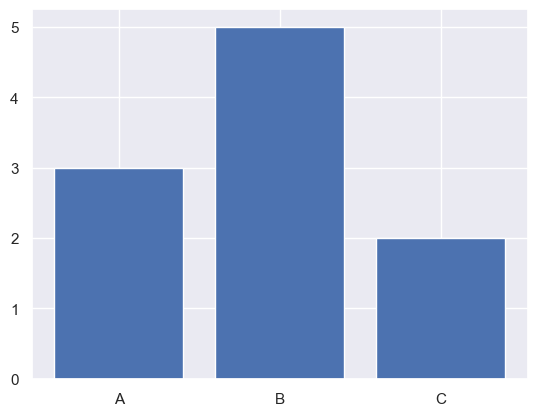

In [88]:
plt.bar(['A', 'B', 'C'], [3, 5, 2])
plt.show()

***Explanation:***
This creates a vertical bar chart. The first list provides the categorical labels for the x-axis, and the second list provides the numerical height for each bar. `plt.show()` displays the chart.

**`plt.hist(data, bins)`**: Histogram.

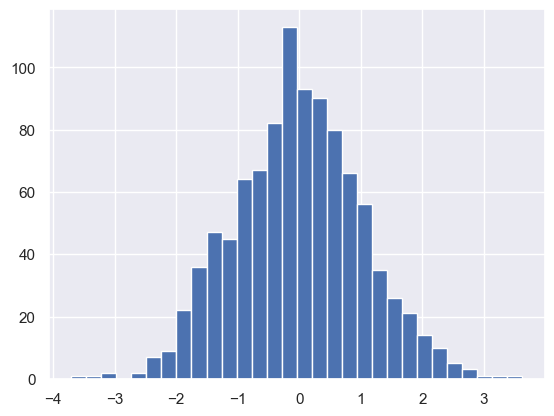

In [89]:
data = np.random.randn(1000)
plt.hist(data, bins=30)
plt.show()

***Explanation:***
This code generates a histogram to visualize the distribution of a dataset. First, it creates 1000 random numbers from a standard normal distribution. Then, `plt.hist()` plots this data, grouping the values into 30 bins. `plt.show()` displays the histogram.

## Seaborn Functions

### Basic Setup

**`sns.set()`**: Apply default Seaborn style.

In [90]:
sns.set()

***Explanation:***
This function is called to apply the default Seaborn styling to all subsequent Matplotlib plots. This makes the plots more aesthetically pleasing and readable.

### Relational Plots

In [91]:
tips = sns.load_dataset("tips")

***Explanation:***
This line loads one of Seaborn's built-in example datasets, the 'tips' dataset, into a pandas DataFrame. This dataset contains information about restaurant tips and will be used for the following Seaborn plot examples.

**`sns.scatterplot(data, x, y)`**: Scatter plot.

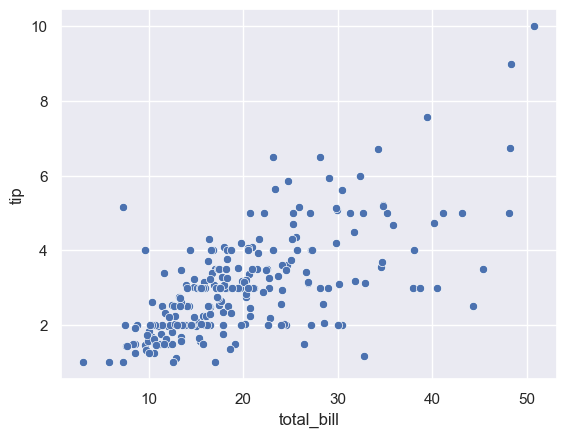

In [92]:
sns.scatterplot(data=tips, x="total_bill", y="tip")
plt.show()

***Explanation:***
This creates a scatter plot using Seaborn to visualize the relationship between two continuous variables: the total bill and the tip amount. It's a more powerful version of `plt.scatter` that integrates well with DataFrames.

**`sns.lineplot(data, x, y)`**: Line plot.

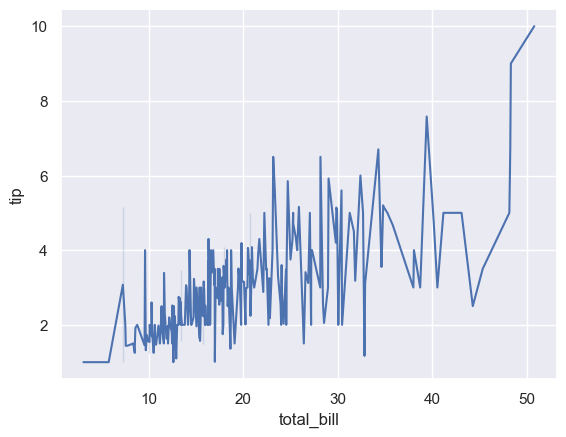

In [93]:
sns.lineplot(data=tips, x="total_bill", y="tip")
plt.show()

***Explanation:***
This creates a line plot that shows the relationship between the total bill and the tip. By default, Seaborn will also show a confidence interval around the line, which represents the uncertainty in the data.

### Categorical Plots

**`sns.barplot(data, x, y)`**: Bar chart with error bars.

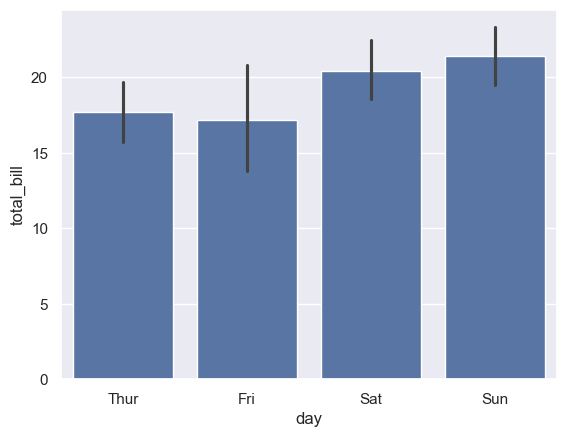

In [94]:
sns.barplot(data=tips, x="day", y="total_bill")
plt.show()

***Explanation:***
This creates a bar plot that shows the relationship between a categorical variable ('day') and a continuous variable ('total_bill'). By default, it shows the mean of the total bill for each day, with error bars indicating the confidence interval.

**`sns.boxplot(data, x, y)`**: Box plot.

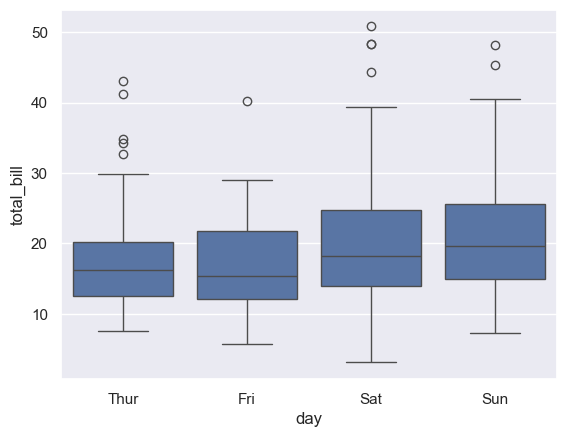

In [95]:
sns.boxplot(data=tips, x="day", y="total_bill")
plt.show()

***Explanation:***
This creates a box plot, which is a powerful way to visualize the distribution of a continuous variable ('total_bill') across different categories ('day'). It shows the median, quartiles, and potential outliers.

**`sns.violinplot(data, x, y)`**: Violin plot.

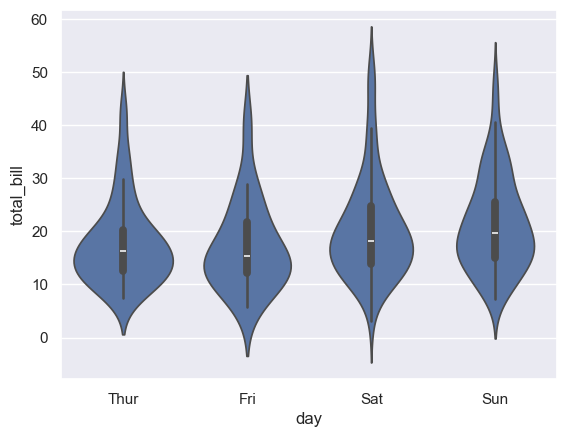

In [96]:
sns.violinplot(data=tips, x="day", y="total_bill")
plt.show()

***Explanation:***
A violin plot is a combination of a box plot and a kernel density plot. It provides a richer description of the data distribution, showing the probability density of the data at different values.

### Distribution Plots

**`sns.histplot(data, x, bins)`**: Histogram.

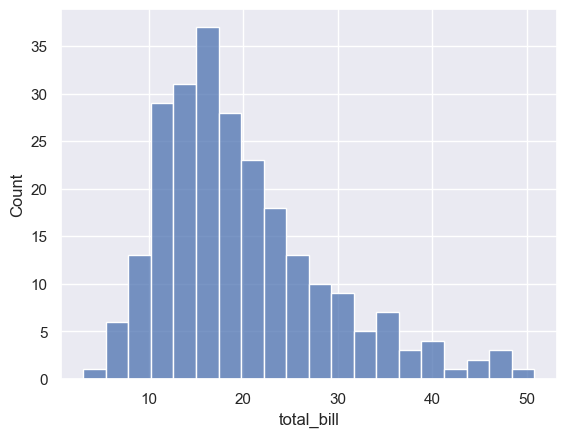

In [97]:
sns.histplot(data=tips, x="total_bill", bins=20)
plt.show()

***Explanation:***
This is Seaborn's version of a histogram. It visualizes the distribution of a single continuous variable ('total_bill') by dividing the data into a specified number of bins (20 in this case).

**`sns.kdeplot(data, x)`**: Kernel Density Estimate.

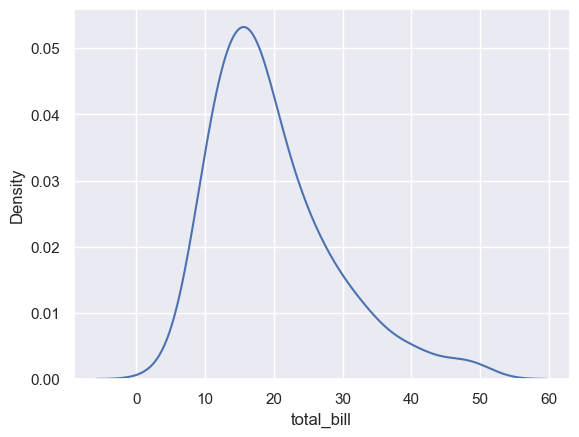

In [98]:
sns.kdeplot(data=tips, x="total_bill")
plt.show()

***Explanation:***
This function plots the Kernel Density Estimate (KDE) of a variable. It represents the data using a continuous probability density curve, which can be seen as a smoothed version of a histogram.

## Other Python Functions

### List Functions

In [99]:
# Creation
my_list = [1, 2, 3, 2]
print(f"Initial list: {my_list}")

# append
my_list.append(4)
print(f"After append(4): {my_list}")

# extend
my_list.extend([5, 6])
print(f"After extend([5, 6]): {my_list}")

# insert
my_list.insert(1, 'a')
print(f"After insert(1, 'a'): {my_list}")

# remove
my_list.remove(2) # Removes first occurrence
print(f"After remove(2): {my_list}")

# pop
popped_item = my_list.pop()
print(f"After pop(): {my_list}, Popped: {popped_item}")

# index
print(f"Index of 3: {my_list.index(3)}")

# count
print(f"Count of 'a': {my_list.count('a')}")

# sort
# Note: sort will fail with mixed types, let's create a numeric list
num_list = [3, 1, 4, 1, 5, 9]
num_list.sort()
print(f"Sorted list: {num_list}")

# reverse
num_list.reverse()
print(f"Reversed list: {num_list}")

# copy
list_copy = num_list.copy()
print(f"Copied list: {list_copy}")

# clear
list_copy.clear()
print(f"Cleared copy: {list_copy}")

Initial list: [1, 2, 3, 2]
After append(4): [1, 2, 3, 2, 4]
After extend([5, 6]): [1, 2, 3, 2, 4, 5, 6]
After insert(1, 'a'): [1, 'a', 2, 3, 2, 4, 5, 6]
After remove(2): [1, 'a', 3, 2, 4, 5, 6]
After pop(): [1, 'a', 3, 2, 4, 5], Popped: 6
Index of 3: 2
Count of 'a': 1
Sorted list: [1, 1, 3, 4, 5, 9]
Reversed list: [9, 5, 4, 3, 1, 1]
Copied list: [9, 5, 4, 3, 1, 1]
Cleared copy: []


***Explanation:***
This code block provides a comprehensive demonstration of common list methods in Python. It shows how to create a list and then sequentially applies and explains methods for adding elements (`append`, `extend`, `insert`), removing elements (`remove`, `pop`, `clear`), accessing elements (`index`, `count`), and ordering elements (`sort`, `reverse`). It also demonstrates how to create a shallow copy of a list.